# **ML based QSAR modeling for bioactivity prediction of Anticancer Activity**

## 1. Libraries

**RDkit:** Provides extensive cheminformatics functionality for working with chemical structures, including fingerprint calculation.    
**Pandas:** Offers robust tools for data manipulation, analysis, and the creation of tabular data structures (DataFrames).  
**ChEMBL web resource client:** Facilitates interaction with the ChEMBL database, allowing you to access and retrieve chemical data programmatically.  
**Scikit-learn:** A versatile machine learning library with a wide range of algorithms for classification, regression, clustering, and more.  


In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 14.5 MB/s eta 0:00:00


In [2]:
!pip install chembl-webresource-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00


## 2. ChEMBL Bioactivity Data Pre-processing

This section covers the steps required to connect to the ChEMBL database, query relevant bioactivity data of P53 MDM2 interaction inhibitors, and perform initial pre-processing to prepare the data for further analysis.


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client

In [4]:
# Target search for inhibation of Cancer Cell
target = new_client.target
target_query = target.search('p53-MDM2 interaction inhibitors')
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,Tumour suppressor p53/oncoprotein Mdm2,32.0,False,CHEMBL1907611,"[{'accession': 'P04637', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
1,[],Homo sapiens,MDM2/MDMX-p53,31.0,False,CHEMBL3883306,"[{'accession': 'P04637', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
2,[],Homo sapiens,Protein cereblon/Tumour suppressor p53/oncopro...,31.0,False,CHEMBL4879538,"[{'accession': 'P04637', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
3,[],Homo sapiens,MDM2-MDMX,30.0,False,CHEMBL4106123,"[{'accession': 'Q00987', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
4,[],Homo sapiens,E3 ubiquitin-protein ligase Mdm2,28.0,False,CHEMBL5023,"[{'accession': 'Q00987', 'component_descriptio...",SINGLE PROTEIN,9606
...,...,...,...,...,...,...,...,...,...
580,[],Homo sapiens,Mitogen-activated protein kinase 14/Mitogen-ac...,1.0,False,CHEMBL6066552,"[{'accession': 'P28482', 'component_descriptio...",PROTEIN FAMILY,9606
581,[],Homo sapiens,Mitogen-activated protein kinase 14/MAP kinase...,1.0,False,CHEMBL6066553,"[{'accession': 'Q8IW41', 'component_descriptio...",PROTEIN FAMILY,9606
582,[],Severe acute respiratory syndrome coronavirus 2,Protein cereblon-SARS-Cov-2 polyprotein,1.0,False,CHEMBL6067603,"[{'accession': 'Q96SW2', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,2697049
583,[],Severe acute respiratory syndrome coronavirus 2,von Hippel-Lindau disease tumor suppressor-SAR...,1.0,False,CHEMBL6067604,"[{'accession': 'P40337', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,2697049


In [5]:
# Target selection
selected_target = targets.target_chembl_id[4]
selected_target

'CHEMBL5023'

In [6]:
# Here we specifiy anticancer activities with IC50 and ug.mL-1
activities = new_client.activity
res = activities.filter(target_chembl_id=selected_target) \
                .filter(standard_type="IC50")

In [7]:
# Save the bioactivity data in Pandas dataframe for processing
df = pd.DataFrame(res, columns=['molecule_chembl_id', 'canonical_smiles', 'standard_type', 'standard_value', 'standard_units'])

In [8]:
df

,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units
0,CHEMBL178578,O=C(O)[C@H](c1ccccc1)N1C(=O)c2cc(I)ccc2NC(=O)[...,IC50,1700.0,nM
1,CHEMBL361103,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...,IC50,200.0,nM
2,CHEMBL182051,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...,IC50,30000.0,nM
3,CHEMBL360540,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...,IC50,13000.0,nM
4,CHEMBL427316,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2Br)N(CC...,IC50,3600.0,nM
...,...,...,...,...,...
5815,CHEMBL6014971,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,IC50,0.24,nM
5816,CHEMBL5805098,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,IC50,0.69,nM
5817,CHEMBL6045300,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,IC50,2.86,nM
5818,CHEMBL6055628,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,IC50,0.25,nM


In [9]:
import os

# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

# Save raw dataset as CSV
df.to_csv('data/a_P53_bioactivity_data_raw.csv', index=False)

## 3. Data curation and labelling of active and inactive compounds
This section focuses on removing duplicate compounds and defining criteria to classify compounds as "active" or "inactive" based on their bioactivity data (e.g. IC50). We'll establish thresholds, and ensure clear labeling for subsequent machine learning model development.

### 3.1 Data curation

In [10]:
df = pd.read_csv("data/a_P53_bioactivity_data_raw.csv")

In [13]:
df2 = df.dropna(subset=['standard_value', 'canonical_smiles']).copy()
df2

,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units
0,CHEMBL178578,O=C(O)[C@H](c1ccccc1)N1C(=O)c2cc(I)ccc2NC(=O)[...,IC50,1700.00,nM
1,CHEMBL361103,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...,IC50,200.00,nM
2,CHEMBL182051,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...,IC50,30000.00,nM
3,CHEMBL360540,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...,IC50,13000.00,nM
4,CHEMBL427316,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2Br)N(CC...,IC50,3600.00,nM
...,...,...,...,...,...
5815,CHEMBL6014971,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,IC50,0.24,nM
5816,CHEMBL5805098,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,IC50,0.69,nM
5817,CHEMBL6045300,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,IC50,2.86,nM
5818,CHEMBL6055628,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,IC50,0.25,nM


In [14]:
# Convert 'standard_value' column to numeric format, replacing non-numeric values with NaN
df2['standard_value'] = pd.to_numeric(df2['standard_value'], errors='coerce')

In [15]:
# Calculate the mean of 'standard_value' grouped by 'molecule_chembl_id'
df2['mean_standard_value'] = df2.groupby('molecule_chembl_id')['standard_value'].transform('mean')

In [16]:
# Drop duplicate compounds and keep the first occurrence
df2.drop_duplicates(subset='molecule_chembl_id', keep='first', inplace=True)

In [17]:
df2

,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units,mean_standard_value
0,CHEMBL178578,O=C(O)[C@H](c1ccccc1)N1C(=O)c2cc(I)ccc2NC(=O)[...,IC50,1700.00,nM,1700.00
1,CHEMBL361103,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...,IC50,200.00,nM,33408.00
2,CHEMBL182051,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...,IC50,30000.00,nM,30000.00
3,CHEMBL360540,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...,IC50,13000.00,nM,13000.00
4,CHEMBL427316,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2Br)N(CC...,IC50,3600.00,nM,3600.00
...,...,...,...,...,...,...
5815,CHEMBL6014971,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,IC50,0.24,nM,0.24
5816,CHEMBL5805098,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,IC50,0.69,nM,0.69
5817,CHEMBL6045300,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,IC50,2.86,nM,2.86
5818,CHEMBL6055628,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,IC50,0.25,nM,0.25


In [18]:
df2.to_csv('data/a_P53_bioactivity_data_processed.csv', index=False)

### 3.2 Data labeling

In [19]:
active=df2.loc[df2['mean_standard_value']<32]
active.shape

(2561, 6)

In [20]:
inactive=df2.loc[df2['mean_standard_value']>64]
inactive.shape

(1546, 6)

In [21]:
%%capture
active["Class"]=1
inactive["Class"]=0

In [22]:
active.head()

,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units,mean_standard_value,Class
119,CHEMBL578028,CC(C)(C)C[C@H]1N[C@@H](C(=O)NCC[C@H](O)CO)[C@H...,IC50,16.4,nM,16.4,1
120,CHEMBL577393,CN1CCN(CCNC(=O)[C@@H]2N[C@H](CC(C)(C)C)[C@]3(C...,IC50,25.7,nM,25.7,1
263,CHEMBL1689398,C=C(C)C(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC...,IC50,6.2,nM,6.2,1
264,CHEMBL1689399,C=C(C)C(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC...,IC50,15.0,nM,15.0,1
265,CHEMBL1689400,C=C(C)C(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC...,IC50,18.0,nM,18.0,1


In [23]:
df3 = pd.concat([active,inactive],axis=0)
df3

,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units,mean_standard_value,Class
119,CHEMBL578028,CC(C)(C)C[C@H]1N[C@@H](C(=O)NCC[C@H](O)CO)[C@H...,IC50,16.4,nM,16.4,1
120,CHEMBL577393,CN1CCN(CCNC(=O)[C@@H]2N[C@H](CC(C)(C)C)[C@]3(C...,IC50,25.7,nM,25.7,1
263,CHEMBL1689398,C=C(C)C(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC...,IC50,6.2,nM,6.2,1
264,CHEMBL1689399,C=C(C)C(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC...,IC50,15.0,nM,15.0,1
265,CHEMBL1689400,C=C(C)C(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC...,IC50,18.0,nM,18.0,1
...,...,...,...,...,...,...,...
5798,CHEMBL5895616,CC(C)N1C(=O)[C@@H]2CCC(=O)N2[C@@H](c2cccc(Cl)c...,IC50,3180.0,nM,3180.0,0
5799,CHEMBL5876634,CC[C@@H](CO)N1C(=O)[C@@H](CC(=O)O)O[C@@H](c2cc...,IC50,611.0,nM,611.0,0
5801,CHEMBL5970296,O=C1N[C@H](c2ccc(Cl)cc2)[C@H](c2ccc(Cl)cc2)O[C...,IC50,973.0,nM,2956.5,0
5803,CHEMBL6028056,O=C1N[C@@H](c2ccc(Cl)cc2)[C@@H](c2ccc(Cl)cc2)O...,IC50,2340.0,nM,5545.0,0


In [24]:
df3.to_csv("data/a_P53_bioactivity_data_labelled.csv", index=None)

## 4. Molecular descriptors calculation
Here we standardize the SMILES molecules and employ molecular fingerprints to represent chemical structures in a way that machine learning algorithms can understand. We'll focus on Morgan fingerprints with depth of 4 (also known as Extended Connectivity Fingerprints 4).


In [25]:
%%capture
import pandas as pd
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

# Load CSV
data = pd.read_csv("data/a_P53_bioactivity_data_labelled.csv")

# Function to standardize molecule
def standardize_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mol = rdMolStandardize.Cleanup(mol)   # Standard cleanup
        mol = rdMolStandardize.FragmentParent(mol)  # Remove salts
        return Chem.MolToSmiles(mol)
    return None

# Apply standardization
data['canonical_smiles'] = data['canonical_smiles'].apply(standardize_molecule)

# Remove failed rows
data = data.dropna(subset=['canonical_smiles'])

# Save file
data.to_csv("data/a_P53_bioactivity_data_labelled_standardized.csv", index=False)

In [26]:
%%capture
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

# Load your DataFrame with SMILES data (corrected filename)
data = pd.read_csv("data/a_P53_bioactivity_data_labelled_standardized.csv")

# Add a 'molecule' column based on 'canonical_smiles'
data['molecule'] = data['canonical_smiles'].apply(Chem.MolFromSmiles)

# Drop rows where molecule creation failed (i.e., SMILES could not be parsed)
data = data.dropna(subset=['molecule'])

# Calculate Morgan fingerprints with depth of 4
num_bits = 2048  # Number of bits in the fingerprint
fingerprints = []

for mol in data['molecule']:
    # Since we dropped rows with None molecules, mol will always be valid here
    fingerprint = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=num_bits)
    fingerprint = list(fingerprint.ToBitString())
    fingerprints.append(fingerprint)

# Convert the list of fingerprints to a DataFrame
fingerprint_df = pd.DataFrame(fingerprints, columns=[f'Morgan_{i}' for i in range(num_bits)])

# Concatenate the original DataFrame with the fingerprint DataFrame
# Reset indices to ensure correct alignment after dropping rows
data = pd.concat([data.reset_index(drop=True), fingerprint_df.reset_index(drop=True)], axis=1)

# Save the DataFrame with Morgan fingerprints to a new CSV file (corrected filename)
data.to_csv("data/a_P53_with_morgan_fingerprints.csv", index=None)

In [27]:
data.shape

(4107, 2056)

## 5. Feature selection

To improve model performance and prevent overfitting, this project employs feature selection techniques. Specifically, we address the following:

**Highly Correlated Features:** Features that exhibit high correlation with each other provide redundant information.  We'll identify and remove highly correlated features (e.g., using a correlation matrix and a threshold like 0.7).

**Low Variance Features:**  Features with very low variance provide little predictive power. We'll use a variance threshold to filter out features that fall below a specified level of variance.

In [28]:
descriptors = pd.read_csv("data/a_P53_with_morgan_fingerprints.csv")

In [29]:
columns_to_drop = ['molecule_chembl_id', 'canonical_smiles', 'standard_type', 'standard_value', 'standard_units', 'mean_standard_value', 'Class', 'molecule']

In [30]:
X = descriptors.drop(columns=columns_to_drop)

In [31]:
X.shape

(4107, 2048)

In [32]:
y = data['Class'] #class being predicted
y

,Class
0,1
1,1
2,1
3,1
4,1
...,...
4102,0
4103,0
4104,0
4105,0


In [33]:
import numpy as np
# Calculate the correlation matrix
corr_matrix = X.corr().abs()

# Set the upper triangle of the correlation matrix to NaN
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation greater than a threshold (e.g., 0.7)
high_corr_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.7)]

# Drop highly correlated columns
X_filtered = X.drop(columns=high_corr_cols)

# Optionally, you can also drop the rows containing NaN values, if any
X_filtered = X_filtered.dropna()

In [34]:
X_filtered.shape

(4107, 1615)

In [35]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np
import pandas as pd

# Assuming X1_filtered is your pandas DataFrame containing the features

selector = VarianceThreshold(threshold=0.01)

# Fit the selector to your training data
selector.fit(X_filtered)

# Get the indices of the features to keep
indices_to_keep = selector.get_support(indices=True)

# Remove low variance features from data and transform back to DataFrame
X_filtered_selected = pd.DataFrame(selector.transform(X_filtered),
                                     columns=X_filtered.columns[indices_to_keep])

In [36]:
X_filtered_selected.shape

(4107, 472)

In [37]:
X_filtered_selected.to_csv('data/a_P53_morgan_fp_selected.csv', index=None)

In [38]:
y.to_csv("data/labels.csv")

## 6. Model Construction and Evaluation
This project explores a range of machine learning algorithms for classification. We'll construct and evaluate the following models:

**Random Forest (RF):** An ensemble method constructs and combines multiple decision trees. Often robust to overfitting and well-suited for nonlinear relationships.  
**Support Vector Machine (SVM):** Finds the optimal hyperplane to separate classes. Excels with linear and nonlinear features (using appropriate kernels).  
**Convolutional Neural Network (CNN):** Deep learning architecture specialized for data with spatial structure (e.g., images). We'll adapt CNNs for working with molecular representations if suitable.  

### 6.1. Data partioning

This code implements a two-step data splitting strategy for machine learning. It performs the following:

**Initial Split:** Divides the dataset into a combined training/testing set (80%) and a separate holdout set (20%).
Train/Validation Split: Further splits the training/testing set into a training set (64% of original data) and a validation set (16% of original data).   
**Purpose:**

**Training:** Use the training set to fit your machine learning models.  
**Validation:** Use the validation set to choose the best-performing model and adjust its settings (hyperparameters).  
**Holdout:** The holdout set is reserved for a final, unbiased evaluation of the selected model's performance on unseen data.

In [39]:
X = pd.read_csv('data/a_P53_morgan_fp_selected.csv')

In [40]:
y = pd.read_csv("data/labels.csv")
y = y['Class']
y

,Class
0,1
1,1
2,1
3,1
4,1
...,...
4102,0
4103,0
4104,0
4105,0


In [41]:
# Import SKlearn modules
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [42]:
# Split your data into train-test set and holdout set
X_train_test, X_holdout, y_train_test, y_holdout = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

# Perform train-validation split on the train-test set
X_train, X_test, y_train, y_test = train_test_split(X_train_test, y_train_test, test_size=0.2, shuffle=True, stratify=y_train_test, random_state=42)

In [43]:
X_train.shape, X_test.shape, X_holdout.shape

((2628, 472), (657, 472), (822, 472))

### 6.2. Random Forest

In [44]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Initialize Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=1, scoring='accuracy', cv=2, verbose=2, random_state=42, n_jobs=-1)

# Perform Randomized Search for hyperparameter tuning
random_search.fit(X_train, y_train)

Fitting 2 folds for each of 1 candidates, totalling 2 fits


RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42),
                   n_iter=1, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      None],
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='accuracy', verbose=2)

In [45]:
# Print the best parameters found
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}


In [46]:
# Use the best parameters to train the Random Forest classifier
rf = RandomForestClassifier(**random_search.best_params_, random_state=42)
rf.fit(X_train_test, y_train_test)

# Evaluate the classifier on the test set
y_pred_test = rf.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
print("Test Set Accuracy:", accuracy_test)

# Evaluate the classifier on the holdout set
y_pred_holdout = rf.predict(X_holdout)
accuracy_holdout = accuracy_score(y_holdout, y_pred_holdout)
print("Holdout Set Accuracy:", accuracy_holdout)

Test Set Accuracy: 0.9330289193302892
Holdout Set Accuracy: 0.8746958637469586


In [47]:
from sklearn.metrics import mean_squared_error

rf_test = rf.predict(X_test)
auc_rf_test = roc_auc_score(y_test, rf_test)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, rf.predict(X_test)))
print("AUC:", auc_rf_test)
print("RMSE:", rmse_rf_test)

AUC: 0.9213933050261677
RMSE: 0.258787713521548


In [48]:
rf_holdout = rf.predict(X_holdout)
auc_rf_holdout = roc_auc_score(y_holdout, rf_holdout)
rmse_rf_holdout = np.sqrt(mean_squared_error(y_holdout, rf.predict(X_holdout)))
print("AUC:", auc_rf_holdout)
print("RMSE:", rmse_rf_holdout)

AUC: 0.8526372565718504
RMSE: 0.35398324289864536


In [49]:
from sklearn.metrics import confusion_matrix
#Generate the confusion matrix
cf_matrix = confusion_matrix(y_test, rf_test)
print(cf_matrix)

[[216  31]
 [ 13 397]]


In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, matthews_corrcoef

# Positive Predictive Value (Precision)
precision = precision_score(y_test, rf_test)

# Confusion Matrix
tn, fp, fn, tp = cf_matrix.ravel()

# Sensitivity (True Positive Rate or Recall)
sensitivity = tp / (tp + fn)

# Specificity
specificity = tn / (tn + fp)

# Negative Predictive Value
npv = tn / (tn + fn)

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, rf_test)

# F1 Score
f1 = f1_score(y_test, rf_test)

# Accuracy
accuracy = accuracy_score(y_test, rf_test)

# Print the calculated metrics
print("Sensitivity (True Positive Rate):", sensitivity)
print("Specificity:", specificity)
print("Positive Predictive Value (Precision):", precision)
print("Negative Predictive Value:", npv)
print("F1 Score:", f1)
print("Accuracy:", accuracy)
print("Matthews Correlation Coefficient (MCC):", mcc)

Sensitivity (True Positive Rate): 0.9682926829268292
Specificity: 0.8744939271255061
Positive Predictive Value (Precision): 0.927570093457944
Negative Predictive Value: 0.9432314410480349
F1 Score: 0.9474940334128878
Accuracy: 0.9330289193302892
Matthews Correlation Coefficient (MCC): 0.856679562785681


### 6.3. Support Vector Machine

In [53]:
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
			'kernel': ['rbf']}

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)

# fitting the model for grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.624 total time=   1.4s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.624 total time=   1.7s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.624 total time=   1.5s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.623 total time=   1.9s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.623 total time=   2.1s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.789 total time=   1.3s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.808 total time=   1.2s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.785 total time=   1.3s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.806 total time=   1.3s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.783 total time=   1.3s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.833 total time=   1.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [54]:
# print best parameter after tuning
print(grid.best_estimator_)

SVC(C=10, gamma=0.01)


In [56]:
# Use the best parameters to train the Random Forest classifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(C=100, gamma=0.01, kernel='rbf', random_state=42, probability=True)
svm.fit(X_train, y_train.to_numpy())
#Evaluate the classifier on the test set
y_pred_test = svm.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
print("Test Set Accuracy:", accuracy_test)
#Evaluate the classifier on the holdout set
y_pred_holdout = svm.predict(X_holdout)
accuracy_holdout = accuracy_score(y_holdout, y_pred_holdout)
print("Holdout Set Accuracy:", accuracy_holdout)



Test Set Accuracy: 0.8964992389649924
Holdout Set Accuracy: 0.8637469586374696


In [57]:
svm_test = svm.predict(X_test)
auc_svm_test = roc_auc_score(y_test, svm_test)
rmse_svm_test = np.sqrt(mean_squared_error(y_test, svm.predict(X_test)))
print("AUC:", auc_svm_test)
print("RMSE:", rmse_svm_test)

AUC: 0.8856867779204106
RMSE: 0.3217153416220737


In [58]:
svm_holdout = svm.predict(X_holdout)
auc_svm_holdout = roc_auc_score(y_holdout, svm_holdout)
rmse_svm_holdout = np.sqrt(mean_squared_error(y_holdout, svm.predict(X_holdout)))
print("AUC:", auc_svm_holdout)
print("RMSE:", rmse_svm_holdout)

AUC: 0.848369575502943
RMSE: 0.369124696224095


In [59]:
from sklearn.metrics import confusion_matrix
#Generate the confusion matrix
cf_matrix = confusion_matrix(y_test, svm_test)
print(cf_matrix)

[[208  39]
 [ 29 381]]


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, matthews_corrcoef

# Positive Predictive Value (Precision)
precision = precision_score(y_test, svm_test)

# Confusion Matrix
tn, fp, fn, tp = cf_matrix.ravel()

# Sensitivity (True Positive Rate or Recall)
sensitivity = tp / (tp + fn)

# Specificity
specificity = tn / (tn + fp)

# Negative Predictive Value
npv = tn / (tn + fn)

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, svm_test)

# F1 Score
f1 = f1_score(y_test, svm_test)

# Accuracy
accuracy = accuracy_score(y_test, svm_test)

# Print the calculated metrics
print("Sensitivity (True Positive Rate):", sensitivity)
print("Specificity:", specificity)
print("Positive Predictive Value (Precision):", precision)
print("Negative Predictive Value:", npv)
print("F1 Score:", f1)
print("Accuracy:", accuracy)
print("Matthews Correlation Coefficient (MCC):", mcc)

Sensitivity (True Positive Rate): 0.9292682926829269
Specificity: 0.8421052631578947
Positive Predictive Value (Precision): 0.9071428571428571
Negative Predictive Value: 0.8776371308016878
F1 Score: 0.9180722891566265
Accuracy: 0.8964992389649924
Matthews Correlation Coefficient (MCC): 0.7780478968890673


# **7. Clustering of Morgan Fingerprint**


In [73]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
import umap

In [78]:
df = pd.read_csv("data/a_P53_morgan_fp_selected.csv")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


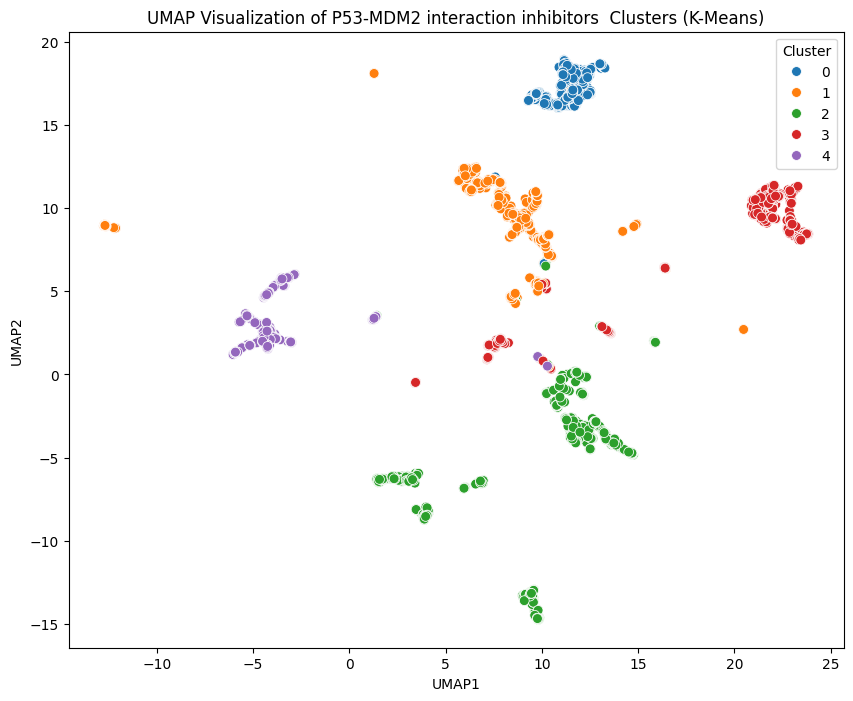

In [92]:
#K-Means Clustering
from sklearn.cluster import KMeans
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(df)
# Dimensionality Reduction + Visualization
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(df)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=labels, palette="tab10", s=50)
plt.title("UMAP Visualization of P53-MDM2 interaction inhibitors  Clusters (K-Means)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="Cluster")
plt.show()